In [2]:
install.packages("remotes")
remotes::install_github("CyrilLagger/scDiffCom")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




BH           (1.87.0-1 -> 1.90.0-1) [CRAN]
dqrng        (0.3.2    -> 0.4.1   ) [CRAN]
RcppAnnoy    (0.0.22   -> 0.0.23  ) [CRAN]
irlba        (2.3.5.1  -> 2.3.7   ) [CRAN]
spatstat.... (3.1-5    -> 3.2-3   ) [CRAN]
spatstat.... (3.1-4    -> 3.2-0   ) [CRAN]
spatstat.... (3.1-8    -> 3.1-9   ) [CRAN]
spatstat.... (3.1-0    -> 3.2-0   ) [CRAN]
spatstat.... (3.4-1    -> 3.5-0   ) [CRAN]
spatstat.... (3.5-0    -> 3.8-1   ) [CRAN]
xtable       (1.8-4    -> 1.8-8   ) [CRAN]
withr        (3.0.2    -> 3.0.3   ) [CRAN]
sourcetools  (0.1.7-1  -> 0.1.7-2 ) [CRAN]
promises     (1.3.3    -> 1.5.0   ) [CRAN]
later        (1.3.1    -> 1.4.8   ) [CRAN]
httpuv       (1.6.16   -> 1.6.17  ) [CRAN]
RcppArmad... (15.0.2-1 -> 15.4.0-1) [CRAN]
reshape2     (1.4.4    -> 1.4.5   ) [CRAN]
ggplot2      (3.5.2    -> 4.0.3   ) [CRAN]
future       (1.67.0   -> 1.70.0  ) [CRAN]
future.apply (1.20.0   -> 1.20.2  ) [CRAN]
gplots       (3.2.0    -> 3.3.0   ) [CRAN]
png          (0.1-8    -> 0.1-9   ) [CRAN]
here       

Skipping 6 packages ahead of CRAN: IRanges, S4Vectors, BiocGenerics, S4Arrays, MatrixGenerics, DelayedArray

Installing 47 packages: BH, dqrng, RcppAnnoy, irlba, spatstat.utils, spatstat.univar, spatstat.data, spatstat.sparse, spatstat.random, spatstat.geom, xtable, withr, sourcetools, promises, later, httpuv, RcppArmadillo, reshape2, ggplot2, future, future.apply, gplots, png, here, tinytex, xfun, openssl, data.table, lazyeval, shiny, zoo, spam, progressr, sp, uwot, spatstat.explore, sctransform, ROCR, reticulate, RcppHNSW, plotly, igraph, ggrepel, fitdistrplus, fastDummies, SeuratObject, Seurat

Warning message in i.p(...):
“installation of package ‘RcppAnnoy’ had non-zero exit status”
Warning message in i.p(...):
“installation of package ‘irlba’ had non-zero exit status”
Warning message in i.p(...):
“installation of package ‘spatstat.utils’ had non-zero exit status”
Warning message in i.p(...):
“installation of package ‘sourcetools’ had non-zero exit status”
Warning message in i.p(.

── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpteoP8t/remotes20ddd43de1500/CyrilLagger-scDiffCom-febe137/DESCRIPTION’ ... OK
* preparing ‘scDiffCom’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘scDiffCom_1.2.0.tar.gz’



In [ ]:
library(scDiffCom)
library(dplyr)
library(tidyr)
library(tidyverse)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.4
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.3     ✔ tibble    3.3.1
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




In [2]:
data_path <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/"
# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

file_path <- file.path(data_path, file_name)

if (file_name == "gated_ImmuneAging.rds"){
    dataset_type <- "immune_aging"
} else if (file_name == "gated_heart_processed.rds"){
    dataset_type <- "heart"
} else if (file_name == "gated_sepsis_processed.rds"){
    dataset_type <- "sepsis"
} else if (file_name == "gated_vaccine_processed.rds"){
    dataset_type <- "vaccine"
} else if (file_name == "gated_our_dataset_processed.rds"){
    dataset_type <- "our_data"
}

In [3]:
seurat_obj <- readRDS(paste0(data_path, file_name))

In [4]:
library(future)

options(future.globals.maxSize = 2 * 1024^3)  # allow up to 2 GB
plan(sequential)

In [5]:
# Run differential analysis with default parameters
scdiffcom_object <- run_interaction_analysis(
  seurat_object = seurat_obj,
  LRI_species = "human",
  seurat_celltype_id = "lineage",
  seurat_condition_id = list(
    column_name = "pla_status",
    cond1_name = "platelet-free", #log(score(cond2_name) / score(cond1_name))
    cond2_name = "PLA"
  )
)

Extracting data from assay 'RNA' and layer 'data' (assuming normalized log1p-transformed data).

Converting normalized data from log1p-transformed to non-log1p-transformed.

Input data: 37487 genes, 163329 cells and 6 cell-types.

Input ligand-receptor database: 4785 human interactions.
Number of LRIs that match to genes present in the dataset: 4751.

Type of analysis to be performed: differential analysis between platelet-free and PLA cells.

Total number of potential cell-cell interactions (CCIs): 171036 (6 * 6 * 4751).

Performing permutation analysis (1000 iterations by batches of 1000) on 6950 potential CCIs.

Performing batch 1 of 1.

Filtering and cleaning 'raw' CCIs.

Returning 3818 detected CCIs.

Performing over-representation analysis on the categories: LRI, LIGAND_COMPLEX, RECEPTOR_COMPLEX, ER_CELLTYPES, EMITTER_CELLTYPE, RECEIVER_CELLTYPE, GO_TERMS, KEGG_PWS.

Successfully returning final scDiffCom object.



In [6]:
CCI_detected <- GetTableCCI(scdiffcom_object, type = "detected", simplified = TRUE)

table(CCI_detected$REGULATION)

ORA_results <- GetTableORA(scdiffcom_object, categories = "all", simplified = TRUE)

names(ORA_results)


DOWN FLAT   UP 
  83 3200  535 

[1] "LRI"               "LIGAND_COMPLEX"    "RECEPTOR_COMPLEX" 
[4] "ER_CELLTYPES"      "EMITTER_CELLTYPE"  "RECEIVER_CELLTYPE"
[7] "GO_TERMS"          "KEGG_PWS"

UP   = stronger / enriched in PLA<br>
DOWN = stronger / enriched in platelet-free<br>
FLAT = no significant differential regulation

=> most unchanged but 535 PLA-up vs 83 platelet-free-up

In [7]:
colnames(CCI_detected)

[1] "CCI"                           "ER_CELLTYPES"                 
 [3] "LRI"                           "NCELLS_EMITTER_platelet-free" 
 [5] "NCELLS_EMITTER_PLA"            "NCELLS_RECEIVER_platelet-free"
 [7] "NCELLS_RECEIVER_PLA"           "CCI_SCORE_platelet-free"      
 [9] "CCI_SCORE_PLA"                 "P_VALUE_platelet-free"        
[11] "BH_P_VALUE_platelet-free"      "P_VALUE_PLA"                  
[13] "BH_P_VALUE_PLA"                "LOGFC"                        
[15] "P_VALUE_DE"                    "BH_P_VALUE_DE"                
[17] "IS_CCI_DETECTED_platelet-free" "IS_CCI_DETECTED_PLA"          
[19] "REGULATION"

In [8]:
colnames(ORA_results$LRI)
colnames(ORA_results$EMITTER_CELLTYPE)
colnames(ORA_results$RECEIVER_CELLTYPE)
colnames(ORA_results$GO_TERMS)

[1] "VALUE"           "OR_UP"           "P_VALUE_UP"      "BH_P_VALUE_UP"  
 [5] "ORA_SCORE_UP"    "OR_DOWN"         "P_VALUE_DOWN"    "BH_P_VALUE_DOWN"
 [9] "ORA_SCORE_DOWN"  "OR_FLAT"         "P_VALUE_FLAT"    "BH_P_VALUE_FLAT"
[13] "ORA_SCORE_FLAT"  "OR_DIFF"         "P_VALUE_DIFF"    "BH_P_VALUE_DIFF"
[17] "ORA_SCORE_DIFF"

[1] "VALUE"           "OR_UP"           "P_VALUE_UP"      "BH_P_VALUE_UP"  
 [5] "ORA_SCORE_UP"    "OR_DOWN"         "P_VALUE_DOWN"    "BH_P_VALUE_DOWN"
 [9] "ORA_SCORE_DOWN"  "OR_FLAT"         "P_VALUE_FLAT"    "BH_P_VALUE_FLAT"
[13] "ORA_SCORE_FLAT"  "OR_DIFF"         "P_VALUE_DIFF"    "BH_P_VALUE_DIFF"
[17] "ORA_SCORE_DIFF"

[1] "VALUE"           "OR_UP"           "P_VALUE_UP"      "BH_P_VALUE_UP"  
 [5] "ORA_SCORE_UP"    "OR_DOWN"         "P_VALUE_DOWN"    "BH_P_VALUE_DOWN"
 [9] "ORA_SCORE_DOWN"  "OR_FLAT"         "P_VALUE_FLAT"    "BH_P_VALUE_FLAT"
[13] "ORA_SCORE_FLAT"  "OR_DIFF"         "P_VALUE_DIFF"    "BH_P_VALUE_DIFF"
[17] "ORA_SCORE_DIFF"

[1] "VALUE"           "VALUE_BIS"       "LEVEL"           "ASPECT"         
 [5] "OR_UP"           "P_VALUE_UP"      "BH_P_VALUE_UP"   "ORA_SCORE_UP"   
 [9] "OR_DOWN"         "P_VALUE_DOWN"    "BH_P_VALUE_DOWN" "ORA_SCORE_DOWN" 
[13] "OR_FLAT"         "P_VALUE_FLAT"    "BH_P_VALUE_FLAT" "ORA_SCORE_FLAT" 
[17] "OR_DIFF"         "P_VALUE_DIFF"    "BH_P_VALUE_DIFF" "ORA_SCORE_DIFF"

In [ ]:
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/scdiffcom"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

saveRDS(
  scdiffcom_object,
  file.path(out_dir, "scdiffcom_object.rds")
)

write.csv(
  CCI_detected,
  file.path(out_dir, "scdiffcom_CCI_detected.csv"),
  row.names = FALSE
)

saveRDS(
  ORA_results,
  file.path(out_dir, "scdiffcom_ORA_results.rds")
)

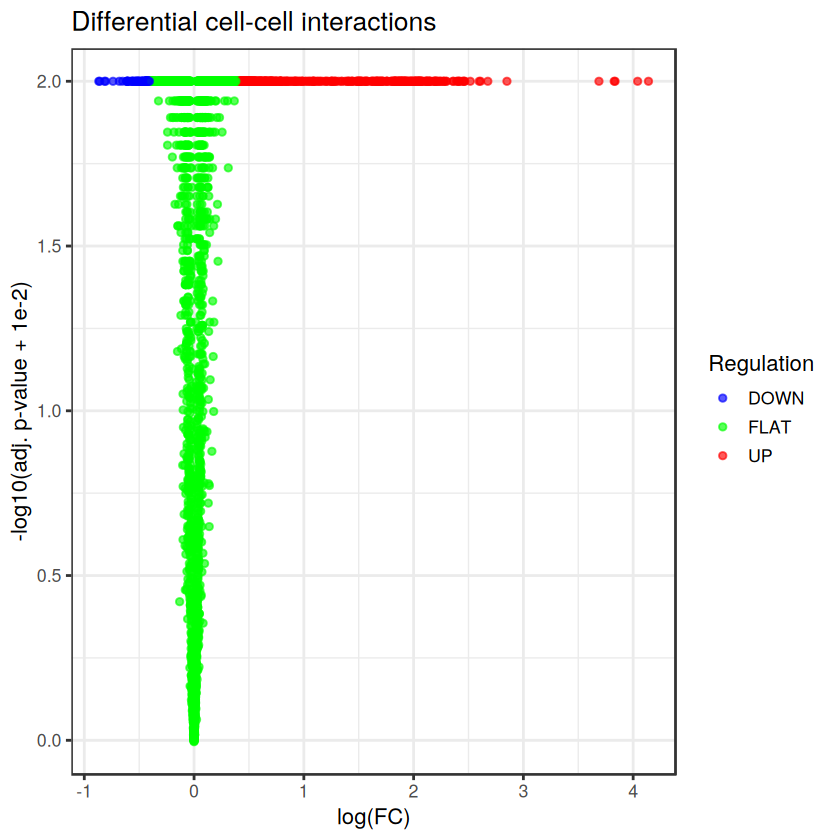

In [20]:
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/differential_ccs/plots/scdiffcom"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

p_cci_volcano_capped <- ggplot(
  CCI_detected,
  aes(
    x = LOGFC,
    y = -log10(BH_P_VALUE_DE + 1E-2),
    colour = REGULATION
  )
) +
  geom_point(alpha = 0.65, size = 1.4) +
  scale_colour_manual(
    values = c(
      "UP" = "red",
      "DOWN" = "blue",
      "FLAT" = "green",
      "NSC" = "grey"
    )
  ) +
  theme_bw(base_size = 13) +
  labs(
    x = "log(FC)",
    y = "-log10(adj. p-value + 1e-2)",
    colour = "Regulation",
    title = "Differential cell-cell interactions"
  )

p_cci_volcano_capped

ggsave(
  file.path(out_dir, "scdiffcom_cci_volcano_capped_yaxis.png"),
  p_cci_volcano_capped,
  width = 8,
  height = 6,
  dpi = 300
)

In [ ]:
# Plot the most over-represented up-regulated LRIs
# PlotORA returns a ggplot object that you can further optimize (e.g. here to place the legend)
p_ora_lri_up <- PlotORA(
  object = scdiffcom_object,
  category = "LRI",
  regulation = "UP"
) +
  theme(
    legend.position = c(0.85, 0.4),
    legend.key.size = unit(0.4, "cm")
  )

ggsave(
  file.path(out_dir, "scdiffcom_ORA_LRI_UP.png"),
  p_ora_lri_up,
  width = 9,
  height = 7,
  dpi = 300
)

In [22]:
p_reg_counts <- CCI_detected %>%
  count(REGULATION) %>%
  ggplot(aes(x = REGULATION, y = n, fill = REGULATION)) +
  geom_col() +
  scale_fill_manual(
    values = c(
      "UP" = "red",
      "DOWN" = "blue",
      "FLAT" = "green",
      "NSC" = "grey"
    )
  ) +
  theme_bw(base_size = 13) +
  labs(
    x = "Regulation",
    y = "# cell-cell interactions",
    fill = "Regulation",
    title = "scDiffCom interaction regulation summary"
  )

ggsave(
  file.path(out_dir, "scdiffcom_regulation_counts.png"),
  p_reg_counts,
  width = 6,
  height = 5,
  dpi = 300
)

In [23]:
p_er_bar <- CCI_detected %>%
  filter(REGULATION %in% c("UP", "DOWN")) %>%
  count(ER_CELLTYPES, REGULATION) %>%
  ggplot(aes(
    x = reorder(ER_CELLTYPES, n),
    y = n,
    fill = REGULATION
  )) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(
    values = c(
      "UP" = "red",
      "DOWN" = "blue"
    )
  ) +
  theme_bw(base_size = 11) +
  labs(
    x = "Emitter-receiver cell types",
    y = "# differential CCIs",
    fill = "Regulation",
    title = "Differential interactions by emitter-receiver pair"
  )


ggsave(
  file.path(out_dir, "scdiffcom_emitter_receiver_barplot.png"),
  p_er_bar,
  width = 10,
  height = 8,
  dpi = 300
)